# Task 02 - Análise Exploratória: Mapa Cultural de Pernambuco

Este notebook analisa exclusivamente os **1.000 perfis individuais reais** selecionados da API do Mapa Cultural de Pernambuco.

Objetivos:

- avaliar a estrutura e o preenchimento dos perfis;
- identificar áreas, tags, funções e subáreas relevantes;
- analisar multidisciplinaridade e combinações de interesses;
- construir uma rede de similaridade baseada em áreas e tags compartilhadas;
- traduzir os resultados em decisões para onboarding, filtros e descoberta no FlowCarreiras.

Não são simulados cidade, procura por mentoria ou comportamento dentro do aplicativo.

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("../data/processed/mapa_cultural_pe_agentes_enriquecido.csv")
df = pd.read_csv(DATA_PATH)

print(f"Registros: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
df.head(3)

Registros: 1,000
Colunas: 21


,id,nome,descricao_curta,tipo_id,tipo_nome,termos_tags,termos_areas,termos_funcoes,termos_etnias,termos_subareas,data_criacao,data_atualizacao,possui_descricao,possui_tags,possui_funcoes,possui_subareas,quantidade_areas,perfil_multidisciplinar,perfil_minimamente_estruturado,ano_criacao,atualizacao_posterior
0,7,Flávio Barbosa da Silva,Assessor de Gestão - FUNDARPE\r\nDoutorando em...,1,Individual,NaN,Design | Gestão Cultural | Patrimônio Cultural,NaN,NaN,Design,2017-03-20 17:20:07,2024-06-11 22:58:06,True,False,False,True,3,True,False,2017,True
1,17,Janaína Branco,"Designer, Doutoranda em Design Estratégico, Ma...",1,Individual,Fundarpe | Secult,Design | Design de Moda | Economia Criativa e ...,NaN,NaN,Design | Design da Informação | Design de Prod...,2017-03-21 14:18:34,2024-06-11 22:58:09,True,True,False,True,4,True,True,2017,True
2,18,Juliana Rezende,.......,1,Individual,NaN,Artesanato | Cultura e Turismo | Gestão Cultural,NaN,NaN,NaN,2017-03-21 14:18:57,2024-06-11 22:58:11,True,False,False,False,3,True,False,2017,True


## 1. Qualidade e estrutura dos perfis

Perguntas:

- Quais campos estão mais preenchidos?
- Quais etapas deveriam receber mais apoio durante o onboarding?
- Quantos perfis possuem uma apresentação minimamente estruturada?

In [2]:
indicadores = [
    "possui_descricao", "possui_tags", "possui_funcoes",
    "possui_subareas", "perfil_multidisciplinar",
    "perfil_minimamente_estruturado", "atualizacao_posterior"
]

resumo_indicadores = (
    df[indicadores].mean().mul(100)
    .sort_values(ascending=False)
    .rename("percentual")
    .to_frame()
)
resumo_indicadores

,percentual
possui_descricao,99.7
atualizacao_posterior,96.1
perfil_multidisciplinar,63.5
possui_subareas,37.4
perfil_minimamente_estruturado,33.6
possui_tags,28.2
possui_funcoes,10.6


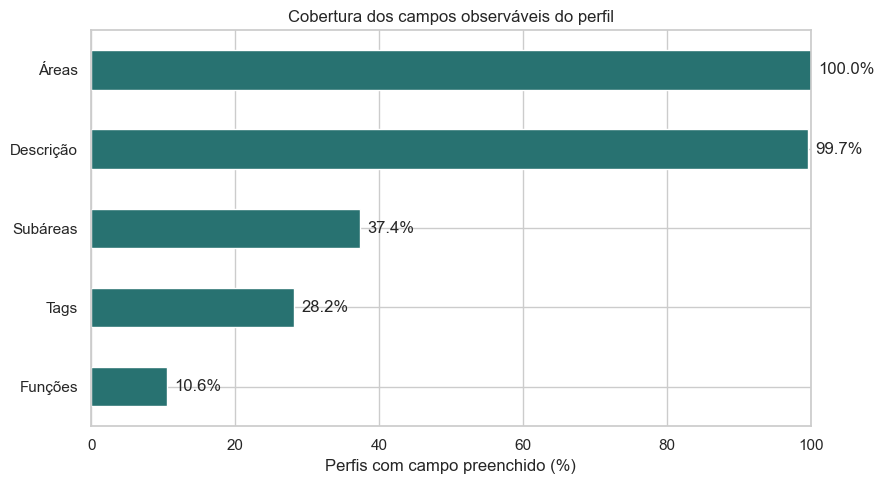

In [3]:
campos = {
    "Descrição": "possui_descricao",
    "Áreas": "termos_areas",
    "Tags": "possui_tags",
    "Funções": "possui_funcoes",
    "Subáreas": "possui_subareas",
}

cobertura = pd.Series({
    nome: (df[coluna].notna().mean() * 100 if coluna == "termos_areas" else df[coluna].mean() * 100)
    for nome, coluna in campos.items()
}).sort_values()

ax = cobertura.plot.barh(figsize=(9, 5), color="#287271")
ax.set(title="Cobertura dos campos observáveis do perfil", xlabel="Perfis com campo preenchido (%)", ylabel="")
ax.set_xlim(0, 100)
for i, valor in enumerate(cobertura):
    ax.text(valor + 1, i, f"{valor:.1f}%", va="center")
plt.tight_layout()
plt.show()

**Interpretação:** descrição e área estão praticamente completas, mas somente **28,2%** possuem tags, **10,6%** informam funções e **37,4%** informam subáreas. Apenas **33,6%** atendem ao critério de perfil minimamente estruturado. Para o FlowCarreiras, isso indica que o onboarding deve explicar claramente o valor de tags, funções e detalhamento profissional.

## 2. Áreas culturais e multidisciplinaridade

Perguntas:

- Quais áreas aparecem com maior frequência?
- Quantas áreas cada perfil declara?
- O produto deve representar artistas multidisciplinares?

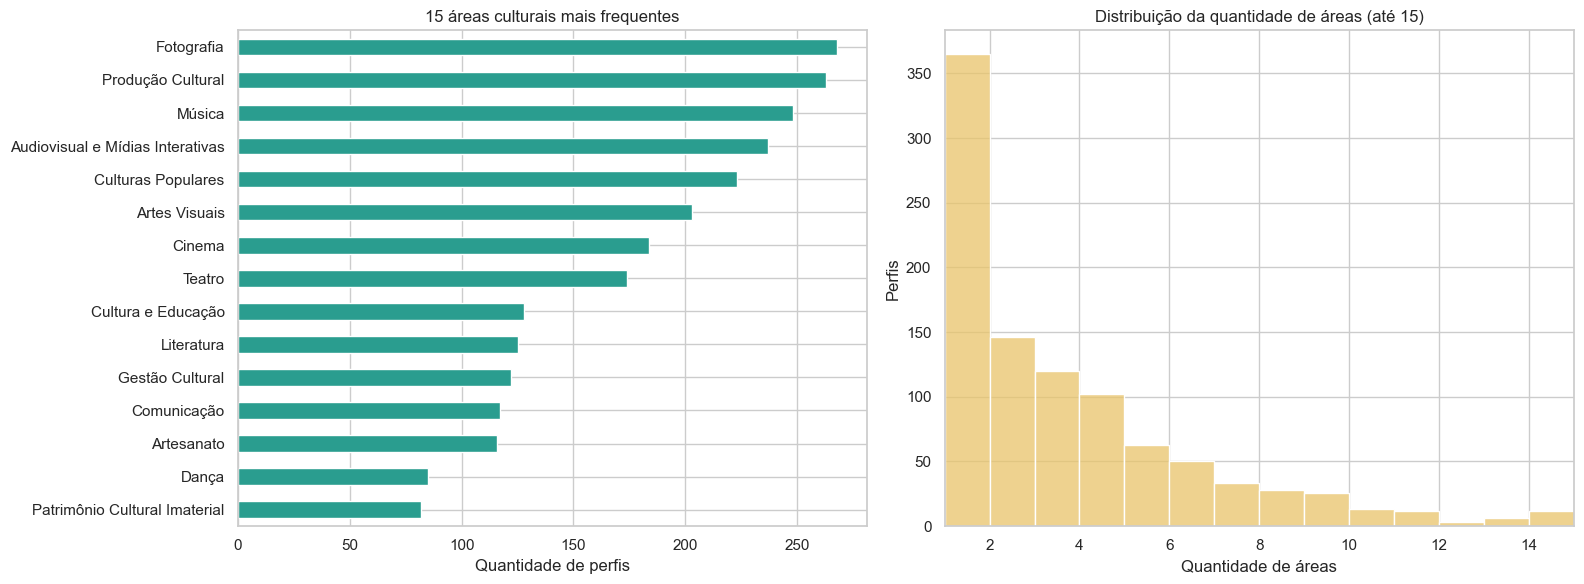

count    1000.000000
mean        3.825000
std         4.847873
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
90%         8.000000
95%        11.000000
99%        21.010000
max        79.000000
Name: quantidade_areas, dtype: float64

In [4]:
def explodir_lista(serie):
    return (
        serie.dropna().astype(str)
        .str.split(" | ", regex=False)
        .explode().str.strip()
        .loc[lambda s: s.ne("")]
    )

areas = explodir_lista(df["termos_areas"])
top_areas = areas.value_counts().head(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_areas.plot.barh(ax=axes[0], color="#2A9D8F")
axes[0].set(title="15 áreas culturais mais frequentes", xlabel="Quantidade de perfis", ylabel="")

sns.histplot(df["quantidade_areas"], bins=range(1, 16), ax=axes[1], color="#E9C46A")
axes[1].set(title="Distribuição da quantidade de áreas (até 15)", xlabel="Quantidade de áreas", ylabel="Perfis")
axes[1].set_xlim(1, 15)
plt.tight_layout()
plt.show()

df["quantidade_areas"].describe(percentiles=[.25, .5, .75, .9, .95, .99])

**Interpretação:** **63,5%** dos perfis declaram mais de uma área. A mediana é 2 áreas, mas existem valores extremos, incluindo um perfil com 79 áreas. O FlowCarreiras deve permitir atuação multidisciplinar, porém pode orientar o usuário a destacar áreas principais para melhorar a clareza e as recomendações.

## 3. Tags, funções e subáreas

Esses campos ajudam a compreender o vocabulário utilizado pelos perfis e podem orientar filtros, sugestões de cadastro e compatibilidade.

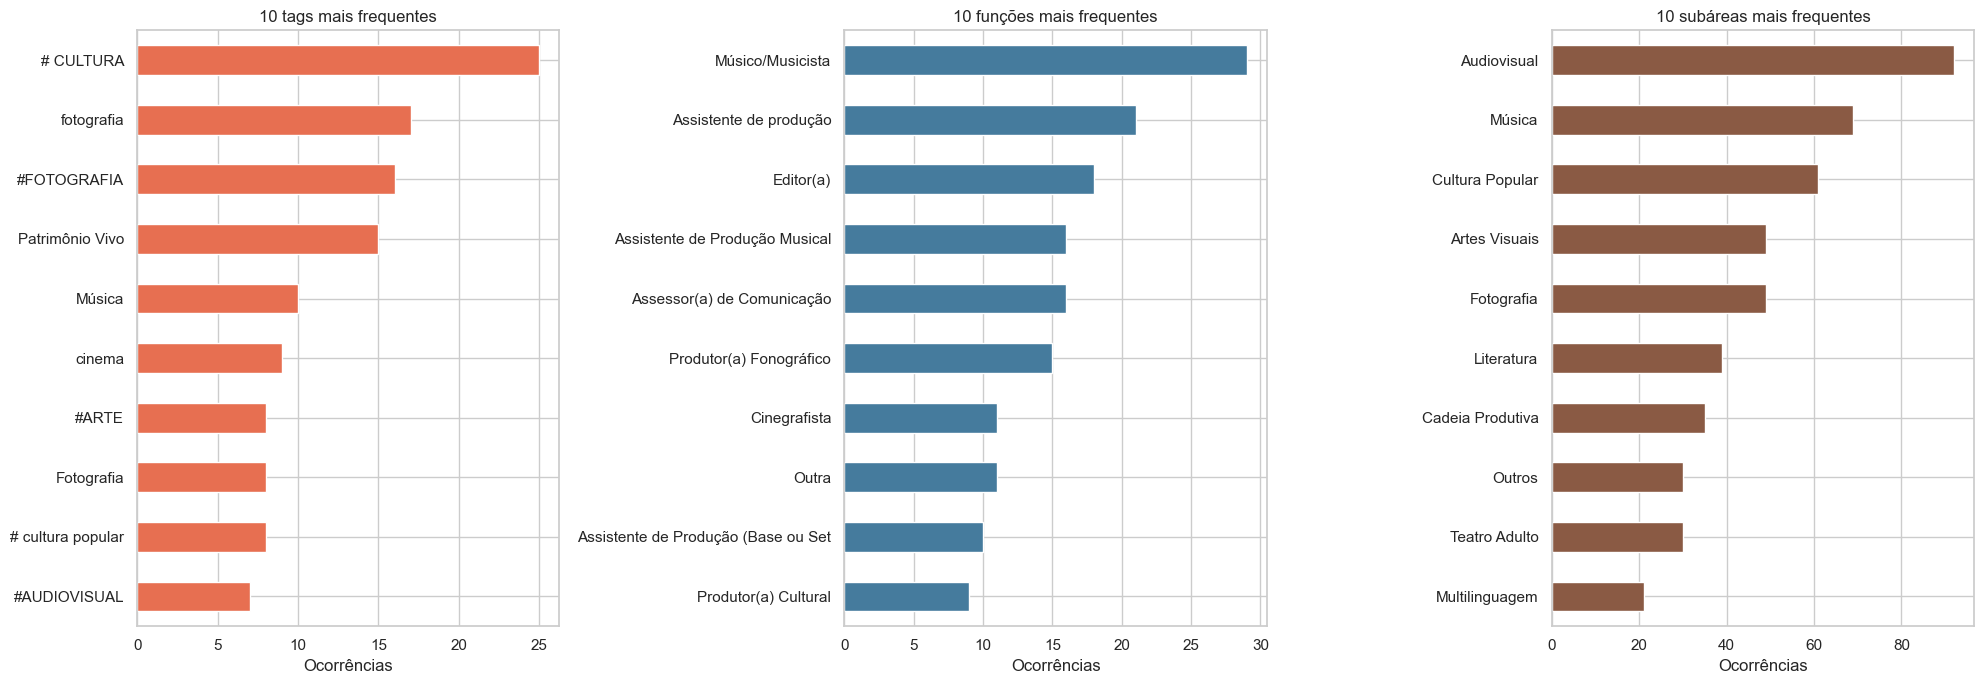

In [5]:
listas = {
    "Tags": explodir_lista(df["termos_tags"]),
    "Funções": explodir_lista(df["termos_funcoes"]),
    "Subáreas": explodir_lista(df["termos_subareas"]),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
cores = ["#E76F51", "#457B9D", "#8A5A44"]

for ax, (titulo, valores), cor in zip(axes, listas.items(), cores):
    valores.value_counts().head(10).sort_values().plot.barh(ax=ax, color=cor)
    ax.set(title=f"10 {titulo.lower()} mais frequentes", xlabel="Ocorrências", ylabel="")

plt.tight_layout()
plt.show()

**Interpretação:** as categorias revelam interesses e funções variadas, mas as tags também apresentam diferenças de capitalização e uso de hashtags, como `fotografia`, `Fotografia` e `#FOTOGRAFIA`. Antes de usar tags em recomendações, o aplicativo deve normalizar variações sem apagar o conteúdo original.

## 4. Coocorrência entre áreas

A coocorrência mostra quais áreas são declaradas juntas no mesmo perfil. Ela ajuda a planejar sugestões relacionadas e filtros combinados.

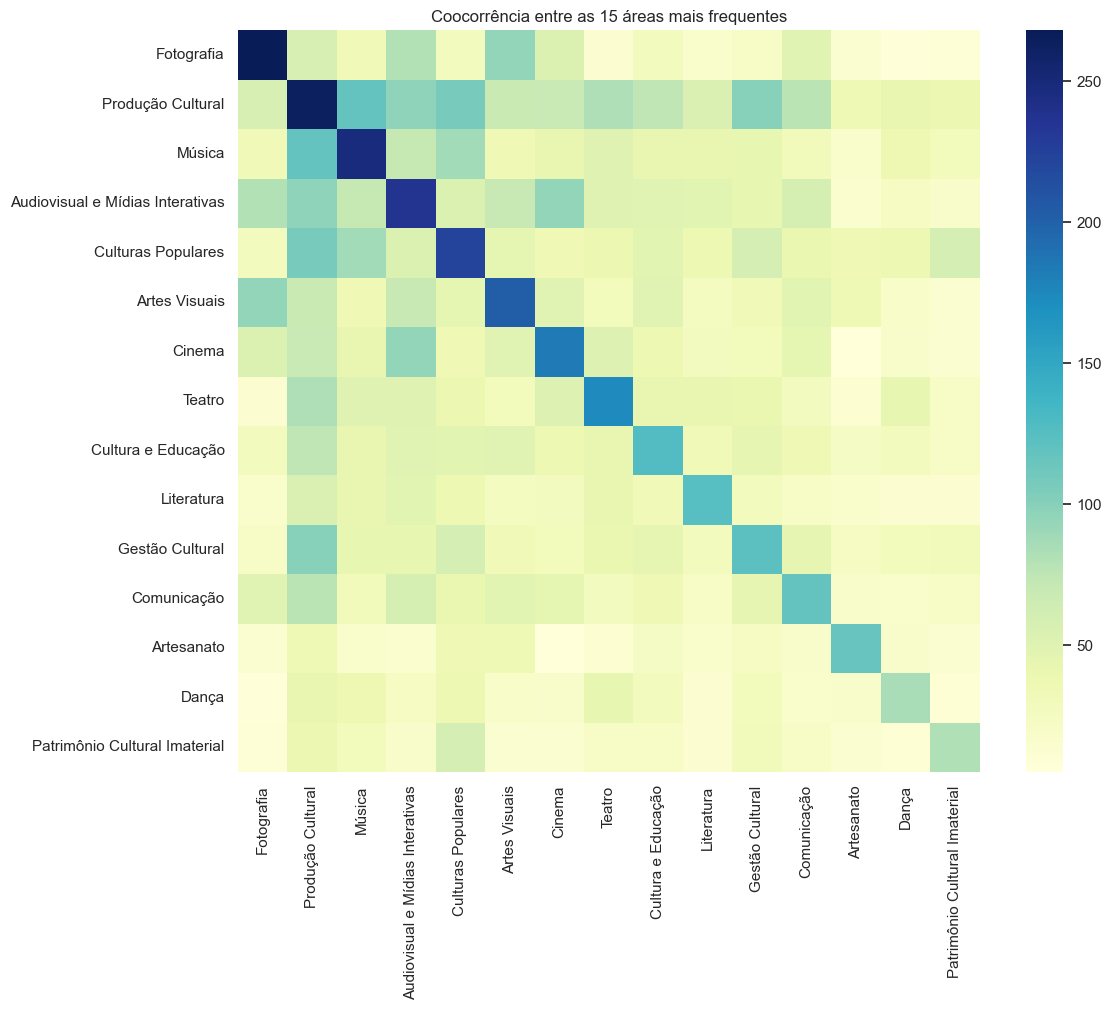

ocorrencias
Produção Cultural                Música                                  118.0
                                 Culturas Populares                      107.0
                                 Gestão Cultural                         100.0
                                 Audiovisual e Mídias Interativas         97.0
Fotografia                       Artes Visuais                            95.0
Audiovisual e Mídias Interativas Cinema                                   95.0
Música                           Culturas Populares                       88.0
Produção Cultural                Teatro                                   83.0
Fotografia                       Audiovisual e Mídias Interativas         80.0
Produção Cultural                Comunicação                              76.0

In [6]:
top_nomes = areas.value_counts().head(15).index.tolist()
matriz_coocorrencia = pd.DataFrame(0, index=top_nomes, columns=top_nomes)

for valor in df["termos_areas"].dropna():
    perfil_areas = sorted(set(item.strip() for item in valor.split(" | ") if item.strip()))
    perfil_top = [item for item in perfil_areas if item in top_nomes]
    for area in perfil_top:
        matriz_coocorrencia.loc[area, area] += 1
    for area_a, area_b in combinations(perfil_top, 2):
        matriz_coocorrencia.loc[area_a, area_b] += 1
        matriz_coocorrencia.loc[area_b, area_a] += 1

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_coocorrencia, cmap="YlGnBu", square=True)
plt.title("Coocorrência entre as 15 áreas mais frequentes")
plt.tight_layout()
plt.show()

pares_areas = (
    matriz_coocorrencia.where(np.triu(np.ones(matriz_coocorrencia.shape), k=1).astype(bool))
    .stack().sort_values(ascending=False).head(10)
    .rename("ocorrencias").to_frame()
)
pares_areas

**Interpretação:** Produção Cultural aparece conectada a Música, Culturas Populares, Gestão Cultural, Audiovisual e Teatro. Também existem combinações específicas fortes, como Artes Visuais com Fotografia e Audiovisual com Cinema. Essas relações podem apoiar sugestões de categorias relacionadas no FlowCarreiras.

## 5. Rede de similaridade por interesses

Cada nó representa um perfil. Uma conexão indica similaridade entre conjuntos de áreas e tags declaradas, e **não uma amizade ou relação social real**.

Para evitar uma rede ilegível, são selecionados perfis com pelo menos dois termos e mantidas apenas conexões com similaridade de cosseno alta.

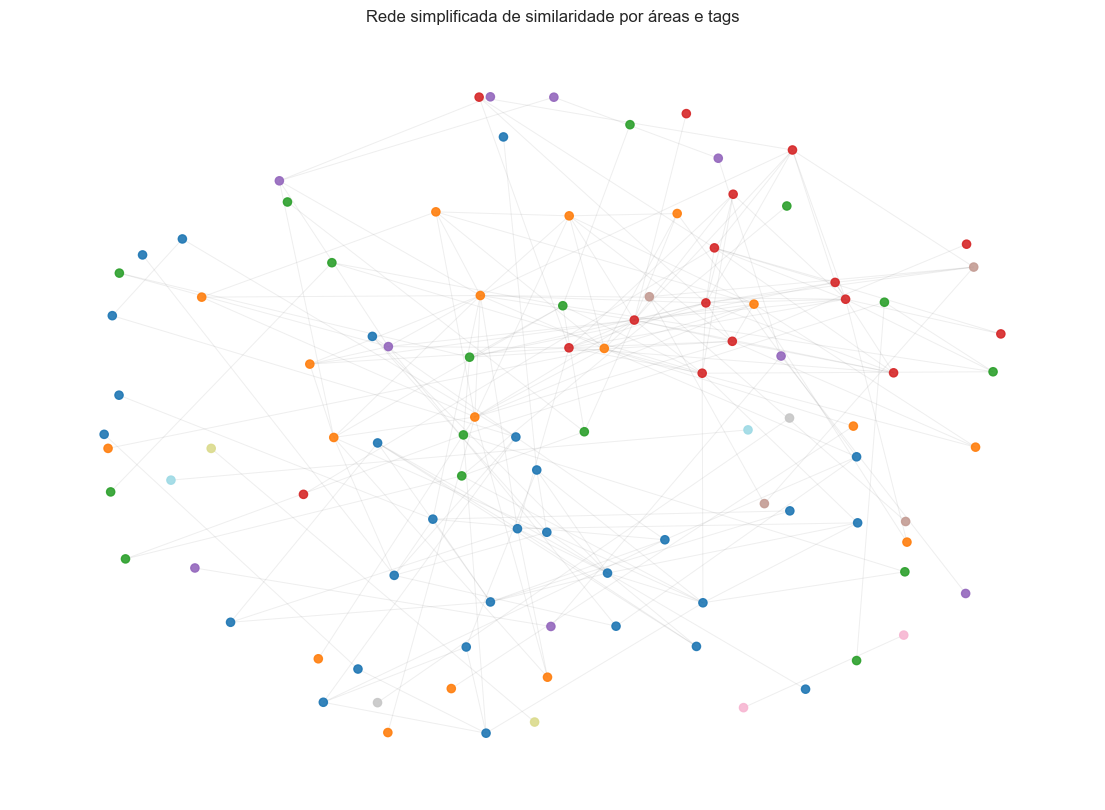

{'perfis_selecionados': 250, 'nos_exibidos': 100, 'conexoes_exibidas': 208, 'comunidades_detectadas': 10}


In [7]:
def termos_do_perfil(row):
    termos = []
    for coluna in ["termos_areas", "termos_tags"]:
        if pd.notna(row[coluna]):
            termos.extend(item.strip().lower() for item in str(row[coluna]).split(" | ") if item.strip())
    return sorted(set(termos))

rede_base = df[["id", "nome", "termos_areas", "termos_tags"]].copy()
rede_base["interesses"] = rede_base.apply(termos_do_perfil, axis=1)
rede_base["quantidade_interesses"] = rede_base["interesses"].str.len()
rede_base = rede_base.loc[rede_base["quantidade_interesses"].ge(2)].nlargest(250, "quantidade_interesses").reset_index(drop=True)

mlb = MultiLabelBinarizer()
matriz_interesses = mlb.fit_transform(rede_base["interesses"])
similaridades = cosine_similarity(matriz_interesses)

G = nx.Graph()
for indice, perfil in rede_base.iterrows():
    G.add_node(indice, nome=perfil["nome"])

limite_similaridade = 0.60
for i in range(len(rede_base)):
    for j in range(i + 1, len(rede_base)):
        if similaridades[i, j] >= limite_similaridade:
            G.add_edge(i, j, weight=float(similaridades[i, j]))

isolados = list(nx.isolates(G))
G.remove_nodes_from(isolados)
comunidades = list(nx.community.greedy_modularity_communities(G)) if G.number_of_edges() else []
cor_comunidade = {no: indice for indice, comunidade in enumerate(comunidades) for no in comunidade}

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.12, width=0.7, edge_color="#777777")
nx.draw_networkx_nodes(
    G, pos,
    node_color=[cor_comunidade.get(no, -1) for no in G.nodes()],
    cmap="tab20", node_size=35, alpha=0.9
)
plt.title("Rede simplificada de similaridade por áreas e tags")
plt.axis("off")
plt.show()

print({
    "perfis_selecionados": len(rede_base),
    "nos_exibidos": G.number_of_nodes(),
    "conexoes_exibidas": G.number_of_edges(),
    "comunidades_detectadas": len(comunidades),
})

**Como interpretar:** comunidades maiores sugerem conjuntos recorrentes de interesses e podem apoiar filtros e descoberta. Perfis conectores podem ajudar a entender combinações multidisciplinares, mas centralidade não deve ser tratada como importância ou qualidade artística.

### 5.1 Ego network: vizinhança de um artista

O ego network aproxima a rede do uso no FlowCarreiras: seleciona um perfil central e mostra apenas os artistas mais semelhantes conectados a ele. O perfil central é escolhido pelo maior número de conexões na rede e são exibidos no máximo 12 vizinhos, priorizados pela similaridade.

A visualização pode apoiar recomendações de artistas, mentores e oportunidades relacionadas. As conexões representam somente interesses declarados em comum, não amizade, qualidade ou relevância artística.


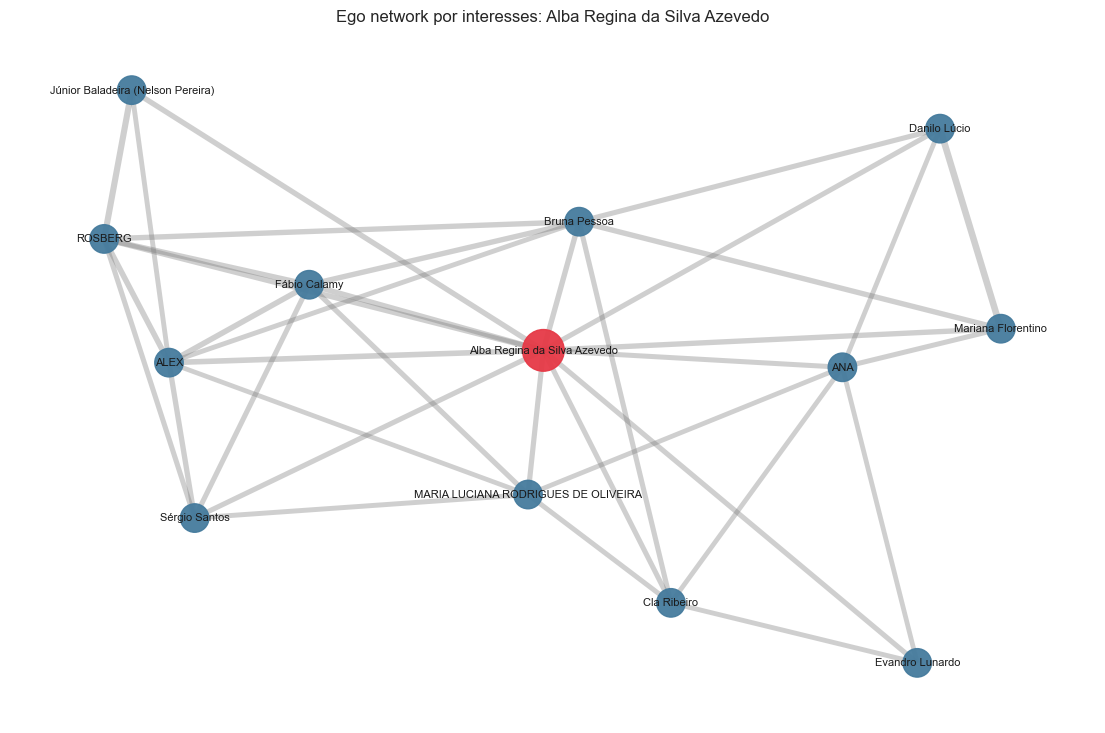

,artista_semelhante,similaridade,interesses_compartilhados
0,ALEX,0.756,"audiovisual e mídias interativas, cinema, cult..."
1,Bruna Pessoa,0.717,"audiovisual e mídias interativas, cinema, comu..."
2,Júnior Baladeira (Nelson Pereira),0.714,"audiovisual e mídias interativas, culturas pop..."
3,ROSBERG,0.714,"audiovisual e mídias interativas, culturas pop..."
4,Fábio Calamy,0.714,"audiovisual e mídias interativas, cinema, cult..."
5,Mariana Florentino,0.714,"audiovisual e mídias interativas, cinema, comu..."
6,MARIA LUCIANA RODRIGUES DE OLIVEIRA,0.684,"audiovisual e mídias interativas, cinema, cult..."
7,Danilo Lúcio,0.668,"audiovisual e mídias interativas, cinema, comu..."
8,Sérgio Santos,0.668,"cinema, culturas populares, literatura, música..."
9,Evandro Lunardo,0.668,"audiovisual e mídias interativas, comunicação,..."


{'artista_central': 'Alba Regina da Silva Azevedo', 'total_conexoes_na_rede': 18, 'vizinhos_exibidos': 12}


In [8]:
if G.number_of_nodes() == 0:
    print("A rede não possui conexões suficientes para construir um ego network.")
else:
    ego = max(G.degree, key=lambda item: item[1])[0]
    vizinhos_ordenados = sorted(
        G[ego].items(),
        key=lambda item: item[1].get("weight", 0),
        reverse=True,
    )[:12]
    nos_ego = [ego] + [vizinho for vizinho, _ in vizinhos_ordenados]
    G_ego = G.subgraph(nos_ego).copy()

    pos_ego = nx.spring_layout(G_ego, seed=42, k=1.1)
    pesos = [G_ego[u][v].get("weight", 0) for u, v in G_ego.edges()]
    larguras = [1 + 4 * peso for peso in pesos]
    cores = ["#e63946" if no == ego else "#457b9d" for no in G_ego.nodes()]
    tamanhos = [900 if no == ego else 420 for no in G_ego.nodes()]
    rotulos = {no: rede_base.loc[no, "nome"] for no in G_ego.nodes()}

    plt.figure(figsize=(14, 9))
    nx.draw_networkx_edges(G_ego, pos_ego, width=larguras, alpha=0.35, edge_color="#777777")
    nx.draw_networkx_nodes(G_ego, pos_ego, node_color=cores, node_size=tamanhos, alpha=0.95)
    nx.draw_networkx_labels(G_ego, pos_ego, labels=rotulos, font_size=8)
    plt.title(f"Ego network por interesses: {rede_base.loc[ego, 'nome']}")
    plt.axis("off")
    plt.show()

    interesses_ego = set(rede_base.loc[ego, "interesses"])
    resumo_vizinhos = []
    for vizinho, atributos in vizinhos_ordenados:
        compartilhados = sorted(interesses_ego.intersection(rede_base.loc[vizinho, "interesses"]))
        resumo_vizinhos.append({
            "artista_semelhante": rede_base.loc[vizinho, "nome"],
            "similaridade": round(atributos.get("weight", 0), 3),
            "interesses_compartilhados": ", ".join(compartilhados),
        })

    display(pd.DataFrame(resumo_vizinhos))
    print({
        "artista_central": rede_base.loc[ego, "nome"],
        "total_conexoes_na_rede": G.degree[ego],
        "vizinhos_exibidos": len(vizinhos_ordenados),
    })


**Como interpretar:** o nó vermelho é o artista central; os nós azuis são perfis recomendáveis por compartilharem áreas ou tags. Linhas mais espessas indicam maior similaridade. No FlowCarreiras, essa lógica poderia alimentar uma seção de descoberta ou sugerir conexões profissionais, sempre explicando quais interesses motivaram cada recomendação.


## 6. Criação e atualização dos registros

Esta análise observa manutenção cadastral. Ela não mede atividade artística fora da plataforma.

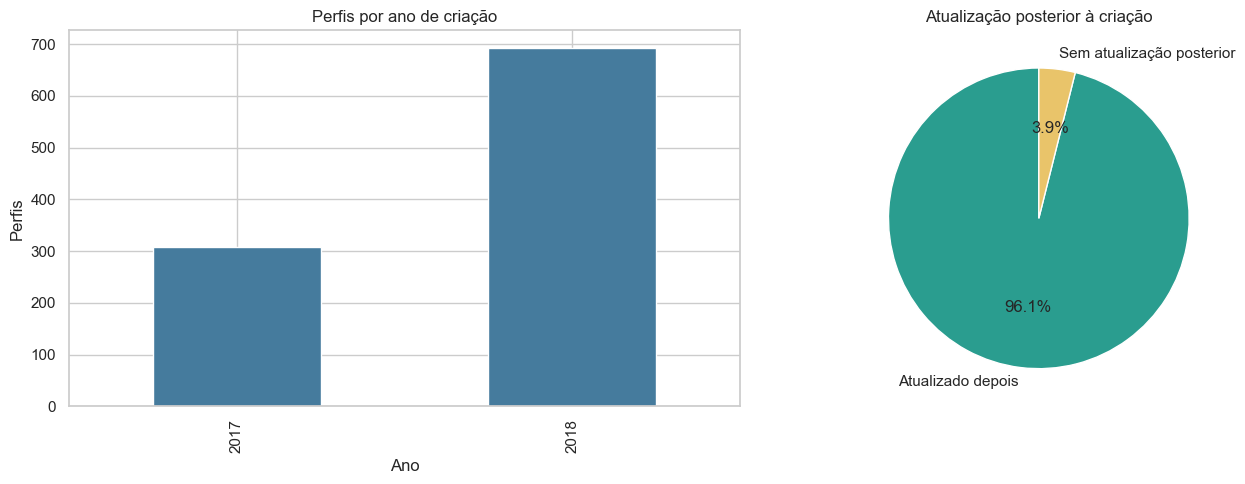

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["ano_criacao"].value_counts().sort_index().plot.bar(ax=axes[0], color="#457B9D")
axes[0].set(title="Perfis por ano de criação", xlabel="Ano", ylabel="Perfis")

df["atualizacao_posterior"].value_counts().rename({True: "Atualizado depois", False: "Sem atualização posterior"}).plot.pie(
    ax=axes[1], autopct="%1.1f%%", startangle=90, colors=["#2A9D8F", "#E9C46A"]
)
axes[1].set(title="Atualização posterior à criação", ylabel="")
plt.tight_layout()
plt.show()

## Principais insights do Mapa Cultural PE

1. O preenchimento é desigual: descrição e área são comuns, enquanto tags, funções e subáreas possuem baixa cobertura.
2. Somente 33,6% dos perfis atendem ao critério de apresentação minimamente estruturada.
3. A multidisciplinaridade é frequente: 63,5% declaram mais de uma área.
4. Produção Cultural aparece como área conectadora em diversas combinações.
5. A rede de interesses pode apoiar descoberta e sugestões, desde que conexões sejam explicadas como similaridade calculada.
6. A base não permite responder sobre município, procura por mentoria ou impacto do FlowCarreiras.